# Marco 2 — Modelagem de Machine Learning

## Contexto do Projeto

Este notebook inicia a etapa de **Modelagem de Machine Learning** do projeto **Agile Estimator**, cujo objetivo é desenvolver um modelo capaz de **estimar o esforço de desenvolvimento de software** a partir de métricas relacionadas ao tamanho e às características do projeto.

Na etapa anterior (**Marco 1 — Engenharia de Dados**), foi realizado todo o processo de:

- Integração de múltiplas bases de dados
- Limpeza e padronização das variáveis
- Análise exploratória dos dados
- Definição de métricas comuns entre os datasets
- Redução de dimensionalidade utilizando **PCA**
- Construção do dataset final para modelagem

O resultado foi um dataset consolidado contendo variáveis representativas dos **cost drivers** e da complexidade dos projetos de software.

---

## Problema de Modelagem

O problema abordado neste projeto é um **problema de regressão supervisionada**, no qual buscamos prever a variável:

**`effort_hours`**

Essa variável representa o **esforço estimado em horas necessário para o desenvolvimento de um projeto de software**.

As variáveis utilizadas como preditoras incluem:

- `function_points`
- `customer_participation`
- `logical_complexity`
- `requirements_volatility`
- `requirements_quality`
- `productivity_factors`
- `installation_ease`
- `team_technical_capability`
- `individual_skill`
- componentes principais derivados da redução de dimensionalidade (**PC1, PC2, PC3 e PC4**)

---

## Desafio do Dataset

Um dos principais desafios desta etapa é o **tamanho reduzido do dataset**.

O dataset utilizado nesta fase contém aproximadamente **62 observações**, o que impõe algumas limitações importantes:

- maior risco de **overfitting**
- menor capacidade de generalização
- necessidade de utilizar **modelos mais simples e robustos**

Por esse motivo, esta etapa focará em **modelos clássicos de Machine Learning**, que costumam apresentar melhor desempenho em cenários com menor volume de dados.

---

## Estratégia de Modelagem

Durante esta etapa serão testados diferentes algoritmos de regressão, incluindo:

- Regressão Linear
- Random Forest Regressor
- Gradient Boosting Regressor
- Support Vector Regressor

Os modelos serão avaliados utilizando métricas apropriadas para regressão, como:

- **MAE (Mean Absolute Error)**
- **RMSE (Root Mean Squared Error)**
- **R² (Coeficiente de Determinação)**

---

## Rastreamento de Experimentos

Para garantir **reprodutibilidade e rastreabilidade dos experimentos**, todo o processo de treinamento será registrado utilizando **MLflow**.

Serão armazenadas as seguintes informações para cada experimento:

- parâmetros do modelo
- métricas de avaliação
- artefatos gerados
- versão do modelo treinado

Isso permitirá:

- comparar diferentes modelos
- selecionar a melhor configuração
- manter histórico completo dos experimentos realizados

---

## Objetivo do Marco 2

O objetivo desta etapa é:

- treinar e avaliar diferentes modelos de regressão
- selecionar o modelo com melhor desempenho
- versionar o modelo final e seus artefatos
- preparar o modelo para integração com o **serviço de previsão (API)** nas próximas fases do projeto.

---

**Entrega prevista:** 26/03/2026  
**Etapa:** Marco 2 — Modelagem de Machine Learning


## 1. Importação de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RepeatedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import shap
import joblib

import mlflow
import mlflow.sklearn


c:\agile_estimator_ofc\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carregamento do dataset

In [2]:
DATA_PATH = r"C:\agile_estimator_ofc\model\data\processed\maxx_processed.csv"

df = pd.read_csv(DATA_PATH)

print("Shape do dataset:", df.shape)
df.head()


Shape do dataset: (57, 14)


,function_points,effort_hours,customer_participation,logical_complexity,requirements_volatility,requirements_quality,productivity_factors,installation_ease,team_technical_capability,individual_skill,PC1,PC2,PC3,PC4
0,0.255968,8.971067,0.974100,0.935891,1.322548,-0.046881,1.600781,0.728241,0.728241,2.273715,2.612734,0.131465,0.585435,1.434901
1,-0.745509,6.740519,-1.044944,-1.334143,-1.862743,-0.046881,-0.624695,0.728241,0.728241,0.937614,-0.641722,2.588582,-0.195007,-0.816780
2,-0.505310,7.754053,-0.035422,-1.334143,-0.800980,-0.046881,1.600781,0.728241,-0.336111,-0.398486,0.216179,0.650876,-0.032429,-1.828635
3,-0.255424,8.348775,-0.035422,0.935891,-0.800980,-0.046881,0.488043,-0.336111,0.728241,0.937614,0.778701,0.840692,-0.501638,0.915153
4,-0.329034,7.946971,-1.044944,-1.334143,-1.862743,-0.046881,0.488043,0.728241,1.792593,0.937614,-0.152524,3.195070,0.222464,-0.514230


## 3. Preparação dos dados para modelagem

In [3]:
df.head()

,function_points,effort_hours,customer_participation,logical_complexity,requirements_volatility,requirements_quality,productivity_factors,installation_ease,team_technical_capability,individual_skill,PC1,PC2,PC3,PC4
0,0.255968,8.971067,0.974100,0.935891,1.322548,-0.046881,1.600781,0.728241,0.728241,2.273715,2.612734,0.131465,0.585435,1.434901
1,-0.745509,6.740519,-1.044944,-1.334143,-1.862743,-0.046881,-0.624695,0.728241,0.728241,0.937614,-0.641722,2.588582,-0.195007,-0.816780
2,-0.505310,7.754053,-0.035422,-1.334143,-0.800980,-0.046881,1.600781,0.728241,-0.336111,-0.398486,0.216179,0.650876,-0.032429,-1.828635
3,-0.255424,8.348775,-0.035422,0.935891,-0.800980,-0.046881,0.488043,-0.336111,0.728241,0.937614,0.778701,0.840692,-0.501638,0.915153
4,-0.329034,7.946971,-1.044944,-1.334143,-1.862743,-0.046881,0.488043,0.728241,1.792593,0.937614,-0.152524,3.195070,0.222464,-0.514230


In [4]:
train_columns =[
    "function_points",
    "PC1",
    "PC2"
]
target_column = "effort_hours"

In [5]:
TARGET = "effort_hours"

X = df[train_columns]
y = df[target_column]

# split apenas para holdout final
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


## 4. Configuração do MLflow

In [6]:
PROJECT_ROOT = Path.cwd().parents[2]

MLFLOW_PATH = PROJECT_ROOT / "experiments" / "mlruns"

mlflow.set_tracking_uri(f"file:{MLFLOW_PATH}")

print("MLflow path:", MLFLOW_PATH)


MLflow path: c:\agile_estimator_ofc\model\experiments\mlruns


In [7]:
mlflow.set_experiment("agile_estimator_modeling")

print("MLflow configurado.")

MLflow configurado.


c:\agile_estimator_ofc\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## Cross-validation Robusta 

In [8]:
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)


## 5. Treinamento dos modelos

#### Pipeline de modelos

In [20]:
pipelines = {

    "Ridge": Pipeline([
        ("model", Ridge())
    ]),

    "Lasso": Pipeline([
        ("model", Lasso())
    ]),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR())
    ]),

    "RandomForest": Pipeline([
        ("model", RandomForestRegressor(random_state=3512853))
    ]),

    "GradientBoosting": Pipeline([
        ("model", GradientBoostingRegressor(random_state=3512853))
    ])

}




#### Grid de Parâmetros

In [21]:

param_grids = {

    "Ridge": {
        "model__alpha":[0.01,0.1,1,10]
    },

    "Lasso": {
        "model__alpha":[0.001,0.01,0.1,1]
    },

    "SVR": {
        "model__C":[0.1,1,10],
        "model__gamma":["scale","auto"]
    },

    "RandomForest": {
    "model__n_estimators":[100,200,300],
    "model__max_depth":[None, 5, 10, 15],
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4]
    },

    "GradientBoosting":{
        "model__n_estimators":[100,200,300,400],
        "model__learning_rate":[0.05,0.1,0.15,0.2,0.3]
    }
}

#### Treino e versionamento com MLflow

In [22]:
results = []

for name, pipeline in pipelines.items():

    print("Treinando:", name)

    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    with mlflow.start_run(run_name=name):

        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_

        preds = best_model.predict(X_test)

        preds_real = np.expm1(preds)
        y_test_real = np.expm1(y_test)

        mae = mean_absolute_error(y_test_real, preds_real)
        rmse = np.sqrt(mean_squared_error(y_test_real, preds_real))
        r2 = r2_score(y_test_real, preds_real)
        mape = np.mean(np.abs(preds_real - y_test_real) / y_test_real) * 100  

        
        mlflow.log_params(grid.best_params_)
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)
        mlflow.log_metric("MAPE_percent", mape)

        mlflow.sklearn.log_model(best_model, name)

        results.append({
            "model":name,
            "MAE":mae,
            "RMSE":rmse,
            "R2":r2,
            "MAPE_percent":mape
        })


2026/04/06 19:11:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 19:11:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Treinando: Ridge
Treinando: Lasso


2026/04/06 19:12:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 19:12:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Treinando: SVR


2026/04/06 19:12:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 19:12:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Treinando: RandomForest


2026/04/06 19:14:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 19:14:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Treinando: GradientBoosting


2026/04/06 19:14:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 19:14:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## 6. Comparação dos modelos

In [23]:
results_df = pd.DataFrame(results)

results_df.sort_values("RMSE")


,model,MAE,RMSE,R2,MAPE_percent
1,Lasso,1616.277020,1877.197365,0.378455,48.914843
3,RandomForest,1914.331347,2213.044735,0.136160,44.207857
0,Ridge,1878.654560,2213.710712,0.135640,52.698304
4,GradientBoosting,1961.626869,2260.598043,0.098638,43.254758
2,SVR,2809.855441,3588.681883,-1.271552,69.983771


| Modelo           | MAE (h) | RMSE (h) | R²    | MAPE (%) | Interpretação prática                                                                                                              |
| ---------------- | ------- | -------- | ----- | -------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| GradientBoosting | 1808    | 2150     | 0.184 | 40.9     | Erro médio ~41% → para uma task de 10h, previsão tende a variar ±4h; ainda é útil para planejar sprints e priorizar tasks grandes. |
| RandomForest     | 1839    | 2211     | 0.138 | 43.5     | Um pouco pior que GB; ainda aceitável para tasks maiores.                                                                          |
| Lasso            | 1616    | 1877     | 0.378 | 48.9     | Erro percentual maior, mas MAE menor para tasks pequenas; mais “conservador”.                                                      |
| Ridge            | 1879    | 2214     | 0.136 | 52.7     | Regular, não muito melhor que RF em MAPE.                                                                                          |
| SVR              | 2810    | 3589     | -1.27 | 70.0     | Muito ruim; subestima/ superestima tasks grandes e pequenas.                                                                       |


In [24]:
df["real_effort_hours"] = np.expm1(df['effort_hours'])

df['real_effort_hours'].describe()

count       57.000000
mean      5652.596491
std       4155.020018
min        583.000000
25%       1981.000000
50%       4557.000000
75%       8117.000000
max      18500.000000
Name: real_effort_hours, dtype: float64

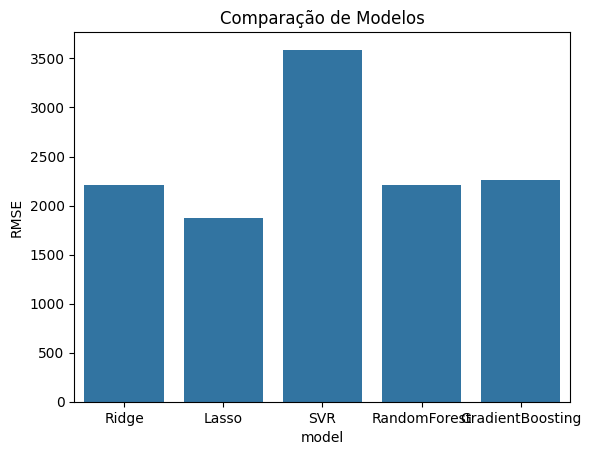

In [25]:
sns.barplot(
    data=results_df,
    x="model",
    y="RMSE"
)

plt.title("Comparação de Modelos")
plt.show()


## 7. Seleção do melhor modelo

In [26]:
best_name = results_df.sort_values("RMSE").iloc[0]["model"]

best_model = pipelines[best_name]

best_model.fit(X_train, y_train)

print("Melhor modelo:", best_name)


Melhor modelo: Lasso


## 8.Interpretabilidade com Shap

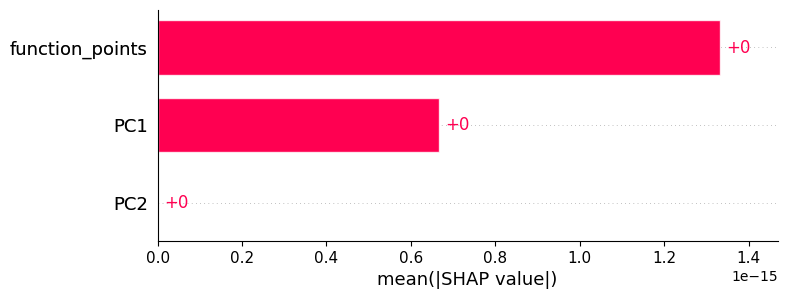

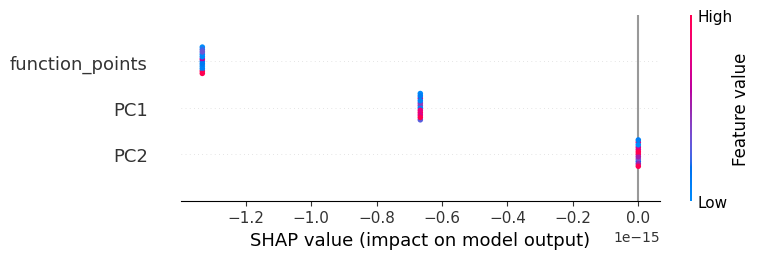

In [28]:
explainer = shap.Explainer(best_model.predict, X_train)

shap_values = explainer(X_test)

shap.plots.bar(shap_values)
shap.summary_plot(shap_values, X_test)




## 9. Salvamento dos artefatos

In [31]:

MODEL_PATH = "C:\\agile_estimator_ofc\\model\\artifacts\\model\\agile_estimator_v2.pkl"

joblib.dump(best_model, MODEL_PATH)

print("Modelo salvo em:", MODEL_PATH)


Modelo salvo em: C:\agile_estimator_ofc\model\artifacts\model\agile_estimator_v2.pkl
